# 04 — Latência

A **latência** mede quanto tempo o sistema leva para entregar a resposta completa ao usuário — do envio da pergunta até o último token impresso. É a terceira dimensão do estudo, depois de acurácia factual e concisão.

**Observação central deste notebook.** Latência foi medida **apenas no canal API** com a ferramenta instrumentada. Os chats web comerciais (ChatGPT e Claude no navegador) usam um pipeline diferente — streaming progressivo, infraestrutura compartilhada com milhões de usuários — e qualquer "latência" medida ali seria comparada com algo distinto da chamada de API ponto-a-ponto. Por integridade metodológica, os chats web ficam ausentes neste notebook (e no de custo, pelo mesmo motivo).

Isso reduz o escopo a **9 modelos via API**. Em compensação, abre espaço para uma análise mais cirúrgica: como o tempo se distribui dentro de cada modelo, e qual é a relação **acurácia factual × latência** — o trade-off central de quem vai colocar isso em produção.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from utils import (carregar_dados, agrega_por_modelo, estilo_padrao,
                   CORES_PROVEDOR, ORDEM_MODELOS, MARKER_API,
                   titulo_acima, anota_sem_sobrepor,
                   legenda_provedor_origem, bootstrap_ic)

estilo_padrao()
df = carregar_dados()
mestre = agrega_por_modelo(df)

# Restringimos a API daqui em diante
df_api = df[df['origem'] == 'API'].copy()
mestre_api = mestre[mestre['origem'] == 'API'].copy()

ORDEM_API = [m for m in ORDEM_MODELOS if m in mestre_api.index]
print(f'{len(df_api)} respostas via API | {len(ORDEM_API)} modelos')

1350 respostas via API | 9 modelos


## 1. Ranking de latência

Tempo médio (em segundos) por resposta, com IC bootstrap 95%. **Menor é melhor.** A escala fica em segundos para preservar a leitura intuitiva.


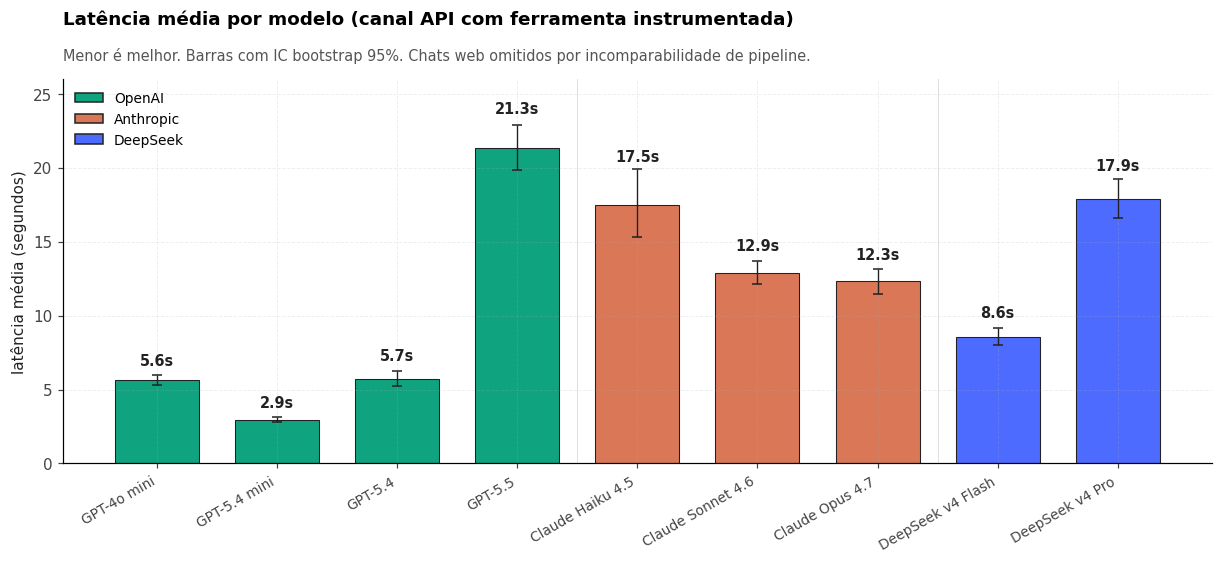

In [2]:
fig, ax = plt.subplots(figsize=(11, 5.0), layout='constrained')

xs = np.arange(len(ORDEM_API))
valores = mestre_api.loc[ORDEM_API, 'latencia_s'].values
cores = mestre_api.loc[ORDEM_API, 'cor'].values

bars = ax.bar(xs, valores, color=cores, edgecolor='#222',
              linewidth=0.7, width=0.7)

# IC bootstrap
for i, m in enumerate(ORDEM_API):
    s = df_api.loc[df_api['modelo_display'] == m, 'latencia_s']
    lo, hi = bootstrap_ic(s, n_boot=2000)
    ax.errorbar(i, s.mean(), yerr=[[s.mean()-lo],[hi-s.mean()]],
                fmt='none', ecolor='#222', elinewidth=0.9, capsize=3, zorder=4)

# Rótulos
for x, m, v in zip(xs, ORDEM_API, valores):
    s = df_api.loc[df_api['modelo_display'] == m, 'latencia_s']
    _, hi = bootstrap_ic(s, n_boot=500)
    ax.text(x, hi + 0.5, f'{v:.1f}s', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#222')

# Separadores de provedor
last = None
for i, p in enumerate(mestre_api.loc[ORDEM_API, 'provedor'].values):
    if last is not None and p != last:
        ax.axvline(i - 0.5, color='#ddd', lw=0.6, zorder=0)
    last = p

ax.set_xticks(xs)
ax.set_xticklabels(ORDEM_API, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latência média (segundos)')
ax.set_ylim(0, max(valores) * 1.22)

# Legenda só de provedor (sem chat web aqui)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],   edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'], edgecolor='#222', label='DeepSeek'),
], loc='upper left', fontsize=9)

titulo_acima(ax,
    'Latência média por modelo (canal API com ferramenta instrumentada)',
    'Menor é melhor. Barras com IC bootstrap 95%. Chats web omitidos por incomparabilidade de pipeline.')

plt.show()

**Três grupos visíveis.**

- **Os ágeis (≤ 6 s)**: GPT-5.4 mini (3,0 s), GPT-4o mini (5,6 s) e GPT-5.4 (5,7 s) — todos da OpenAI. Devolvem a resposta no tempo de uma frase falada.
- **A faixa intermediária (8–13 s)**: DeepSeek v4 Flash (8,6 s), Claude Opus 4.7 (12,3 s) e Claude Sonnet 4.6 (12,9 s). O modelo "Flash" da DeepSeek é o único não-OpenAI nessa zona.
- **Os mais lentos (17–22 s)**: Claude Haiku 4.5 (17,5 s), DeepSeek v4 Pro (17,9 s) e GPT-5.5 (21,3 s).

**Observação contraintuitiva sobre o Haiku.** O Haiku é nominalmente o modelo mais leve da Anthropic, mas no contexto deste estudo ele aparece **mais lento** que Opus e Sonnet. A explicação está no fluxo: o Haiku, sendo menos preciso, tende a fazer mais chamadas à ferramenta antes de chegar à resposta — o que aumenta o tempo total mesmo com latência por chamada menor. O notebook 05 (custo) mostra esse mesmo efeito num outro eixo.

**GPT-5.5: a contrapartida da acurácia factual líder.** O modelo mais preciso do estudo (99,7%) é também o mais lento via API (21,3 s). Aqui está o trade-off central que motiva os scatters a seguir.


## 2. Distribuição da latência (variabilidade por modelo)

A média acima esconde a forma da distribuição. Algumas latências são consistentes — pergunta após pergunta o modelo entrega num tempo parecido. Outras oscilam muito, o que importa para experiência de uso (esperar 10 s na média não é o mesmo que esperar 4 s às vezes e 25 s outras).


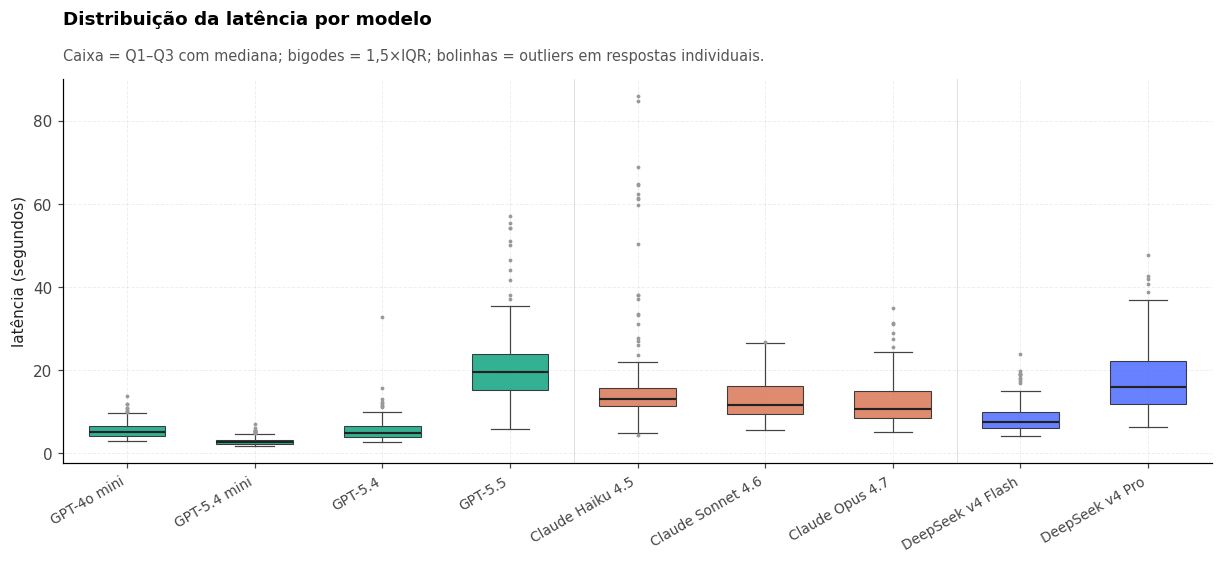

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.0), layout='constrained')

dados = [df_api.loc[df_api['modelo_display'] == m, 'latencia_s'].dropna().values
         for m in ORDEM_API]

bp = ax.boxplot(dados, positions=np.arange(len(ORDEM_API)),
                widths=0.6, patch_artist=True,
                medianprops=dict(color='#222', lw=1.4),
                flierprops=dict(marker='o', markersize=2.5,
                                markerfacecolor='#999', markeredgecolor='none'),
                whiskerprops=dict(color='#444', lw=0.8),
                capprops=dict(color='#444', lw=0.8))

for patch, cor in zip(bp['boxes'], mestre_api.loc[ORDEM_API, 'cor'].values):
    patch.set_facecolor(cor)
    patch.set_edgecolor('#222')
    patch.set_linewidth(0.7)
    patch.set_alpha(0.85)

# Separadores
last = None
for i, p in enumerate(mestre_api.loc[ORDEM_API, 'provedor'].values):
    if last is not None and p != last:
        ax.axvline(i - 0.5, color='#ddd', lw=0.6, zorder=0)
    last = p

ax.set_xticks(np.arange(len(ORDEM_API)))
ax.set_xticklabels(ORDEM_API, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('latência (segundos)')

titulo_acima(ax,
    'Distribuição da latência por modelo',
    'Caixa = Q1–Q3 com mediana; bigodes = 1,5×IQR; bolinhas = outliers em respostas individuais.')

plt.show()

**Padrões na distribuição.**

- **GPT-5.4 mini é o mais consistente**: caixa estreita ao redor de 3 s, poucos outliers. Bom para uso em produção sob SLA.
- **GPT-5.5 e DeepSeek v4 Pro têm caixas longas e cauda pesada**. Algumas respostas passam de 40 s. Isso conversa com o que se vê no fluxo interno (notebook 05): mais chamadas à ferramenta de busca quando a pergunta é mais difícil.
- **Modelos Anthropic mostram bimodalidade leve** — uma cauda visível para cima em todos os três. Compatível com fluxo agentico que ora resolve rápido, ora itera bastante.


## 3. Acurácia factual × latência: o trade-off central

Este é o gráfico que importa para decisão de produção. O canto superior esquerdo é o ideal: alta acurácia factual, baixa latência. Quanto mais para a direita, mais tempo de espera; quanto mais para baixo, menos confiável.


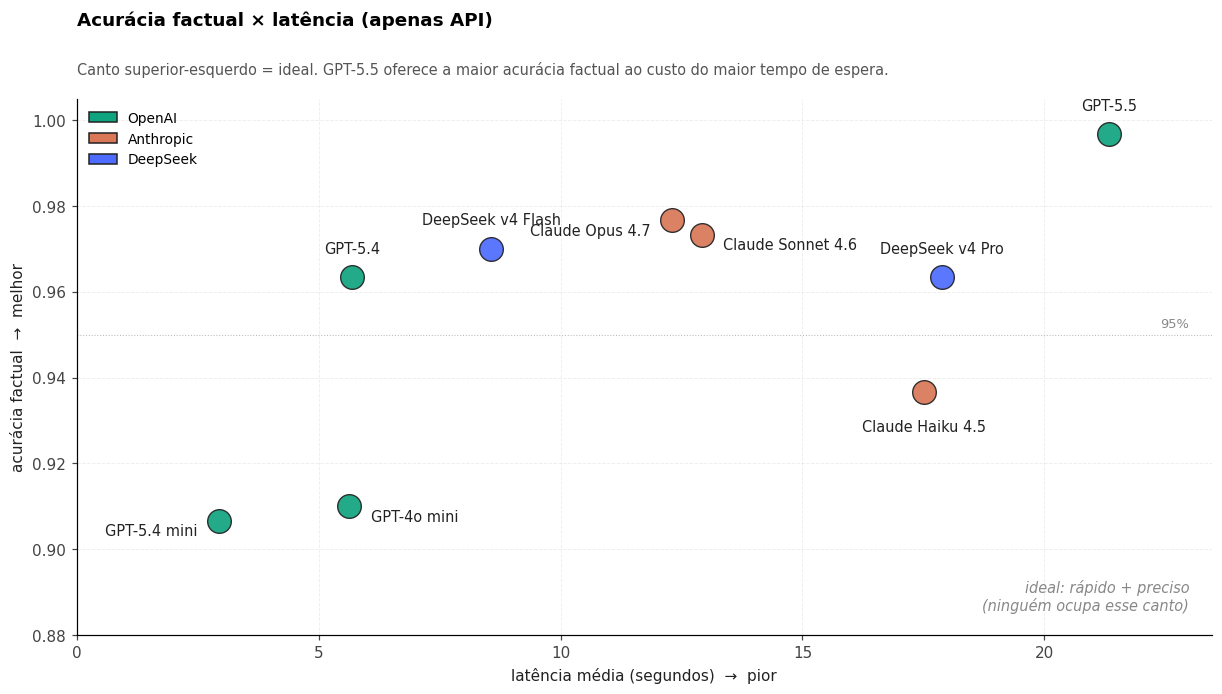

In [4]:
fig, ax = plt.subplots(figsize=(11, 6.2), layout='constrained')

for nome, row in mestre_api.iterrows():
    ax.scatter(row['latencia_s'], row['precisao'],
               s=240, color=row['cor'], marker=MARKER_API,
               edgecolor='#222', linewidth=0.9, zorder=3, alpha=0.92)

# Quadrante ideal: faixa superior-esquerda
ax.axhline(0.95, ls=':', color='#bbb', lw=0.7, zorder=1)
ax.text(0.98, 0.951, '95%', fontsize=8.5, color='#888',
        transform=ax.get_yaxis_transform(), va='bottom', ha='right')

# Rótulos (editáveis)
anota_sem_sobrepor(ax,
    mestre_api['latencia_s'].values,
    mestre_api['precisao'].values,
    mestre_api.index.tolist(),
    fontsize=9.5,
    offsets_manuais={
        'GPT-4o mini':        ( 14,  -2),
        'GPT-5.4 mini':       (-14,  -2),
        'GPT-5.4':            ( 0,  14),
        'GPT-5.5':            ( 0,  14),
        'Claude Haiku 4.5':   ( 0, -18),
        'Claude Sonnet 4.6':  (14,  -2),
        'Claude Opus 4.7':    (-14, -2),
        'DeepSeek v4 Flash':  ( 0,  14),
        'DeepSeek v4 Pro':    ( 0,  14),
    })

ax.set_xlim(0, mestre_api['latencia_s'].max() * 1.10)
ax.set_ylim(0.88, 1.005)
ax.set_xlabel('latência média (segundos)  →  pior')
ax.set_ylabel('acurácia factual  →  melhor')

from matplotlib.patches import Patch
leg = ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],   edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'], edgecolor='#222', label='DeepSeek'),
], loc='upper left', fontsize=9)
leg.set_zorder(5)

# Anotação só do quadrante ideal, no canto inferior direito (vazio)
ax.text(0.98, 0.04, 'ideal: rápido + preciso\n(ninguém ocupa esse canto)',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9.5, color='#888', fontstyle='italic')

titulo_acima(ax,
    'Acurácia factual × latência (apenas API)',
    'Canto superior-esquerdo = ideal. GPT-5.5 oferece a maior acurácia factual ao custo do maior tempo de espera.')

plt.show()

**Como ler.** A nuvem se divide em duas zonas:

- **Zona ágil (esquerda)**: GPT-5.4 mini, GPT-4o mini, GPT-5.4 e DeepSeek v4 Flash. Latências entre 3 s e 9 s. Dentro dela, o **DeepSeek v4 Flash** é o mais preciso (97,0%), mas o **GPT-5.4** vem logo atrás (96,3%) com tempo parecido. Os dois minis OpenAI ficam abaixo de 92% — boa velocidade não compensa acurácia factual fraca.
- **Zona alta-acurácia factual (direita)**: Claude Opus 4.7, Sonnet 4.6, DeepSeek v4 Pro, Claude Haiku 4.5, GPT-5.5. Latências entre 12 s e 22 s. Aqui o **GPT-5.5 é claramente outlier** — pagamos 70% a mais de tempo (21,3 s vs 12,3 s do Opus) por 2 pontos a mais de acurácia factual (99,7% vs 97,7%).

Não há almoço grátis: nenhum modelo entrega simultaneamente o melhor tempo *e* a melhor acurácia factual. As escolhas pragmáticas dependem do uso:

- **Atendimento síncrono**: GPT-5.4 ou DeepSeek v4 Flash.
- **Batch / qualidade máxima**: GPT-5.5 ou Claude Opus 4.7.
- **A pior escolha do plano** seria GPT-5.5 mini quando se quer baixa latência, ou Claude Haiku 4.5 quando se quer baixa latência *e* alta acurácia factual — em ambos os casos há alternativas estritamente melhores.


## 4. Concisão × latência

Pergunta auxiliar: respostas mais longas demoram mais para serem entregues? Em parte sim — gerar texto leva tempo. Mas como o estudo mostrou, o fluxo interno (chamadas à ferramenta) é o que mais varia entre modelos. Este scatter explora qual relação fica mais forte.


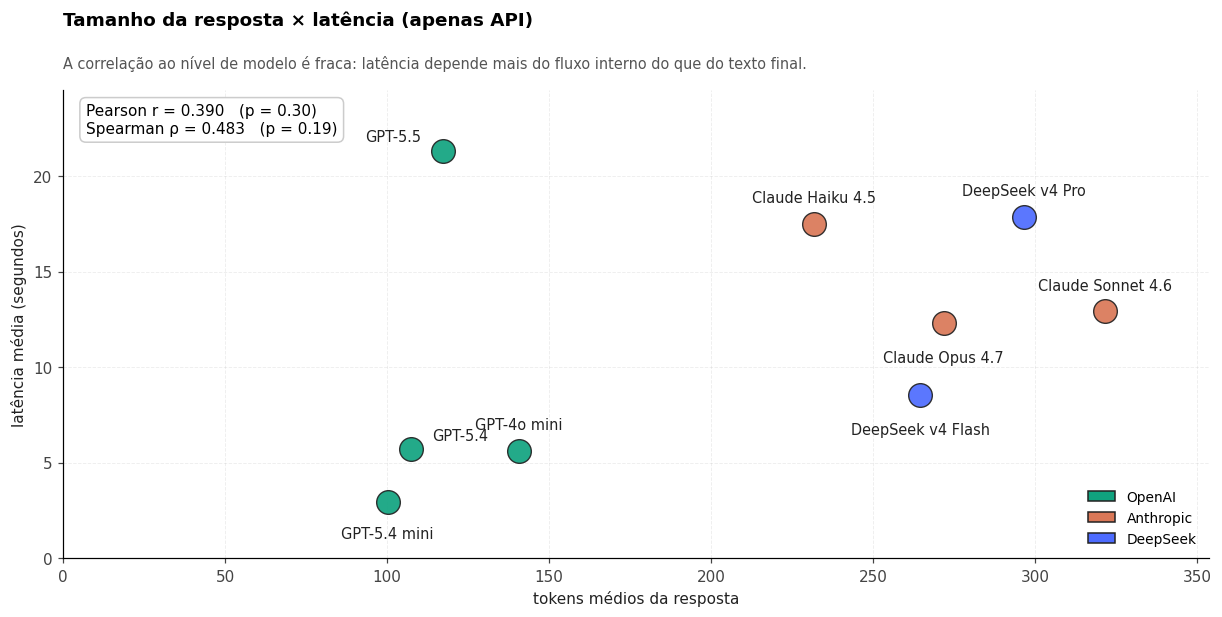

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5), layout='constrained')

for nome, row in mestre_api.iterrows():
    ax.scatter(row['tokens_resp'], row['latencia_s'],
               s=240, color=row['cor'], marker=MARKER_API,
               edgecolor='#222', linewidth=0.9, zorder=3, alpha=0.92)

r_p, p_p = stats.pearsonr(mestre_api['tokens_resp'], mestre_api['latencia_s'])
r_s, p_s = stats.spearmanr(mestre_api['tokens_resp'], mestre_api['latencia_s'])

anota_sem_sobrepor(ax,
    mestre_api['tokens_resp'].values,
    mestre_api['latencia_s'].values,
    mestre_api.index.tolist(),
    fontsize=9.5,
    offsets_manuais={
        'GPT-4o mini':        ( 0,  12),
        'GPT-5.4 mini':       ( 0, -16),
        'GPT-5.4':            ( 14,  4),
        'GPT-5.5':            (-14,  4),
        'Claude Haiku 4.5':   ( 0,  12),
        'Claude Sonnet 4.6':  ( 0,  12),
        'Claude Opus 4.7':    ( 0, -18),
        'DeepSeek v4 Flash':  ( 0, -18),
        'DeepSeek v4 Pro':    ( 0,  12),
    })

ax.set_xlim(0, mestre_api['tokens_resp'].max() * 1.10)
ax.set_ylim(0, mestre_api['latencia_s'].max() * 1.15)
ax.set_xlabel('tokens médios da resposta')
ax.set_ylabel('latência média (segundos)')

ax.text(0.02, 0.97,
        f'Pearson r = {r_p:.3f}   (p = {p_p:.2f})\n'
        f'Spearman ρ = {r_s:.3f}   (p = {p_s:.2f})',
        transform=ax.transAxes, va='top', ha='left',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ccc'))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],   edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'], edgecolor='#222', label='DeepSeek'),
], loc='lower right', fontsize=9)

titulo_acima(ax,
    'Tamanho da resposta × latência (apenas API)',
    'A correlação ao nível de modelo é fraca: latência depende mais do fluxo interno do que do texto final.')

plt.show()

**A correlação é mais fraca do que se poderia esperar** — bem menos forte que a correlação entre tokens e taxa de concisão vista no notebook 03. Isso confirma que o que faz o tempo passar não é o texto entregue ao usuário, mas o que acontece *antes* dele: planejamento, chamadas à ferramenta de busca, leitura de trechos do edital. Esse fluxo interno é o protagonista do **notebook 05 (custo)** — é onde o output_tokens completo (raciocínio + tool-calls + resposta) entra em cena.

---

O notebook 05 abre o custo, fechando as quatro dimensões. O 06 sintetiza tudo num plot integrado e propõe um score híbrido transparente.
